In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN, ProjectRowstoL1NormBall
from bss.PredictiveDecorrBSS import PredictiveDecorrBSS

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 100000
NumberofSources = 5
NumberofMixtures = NumberofSources + 5

S = generate_uncorrelated_uniform_sources(NumberofSources, N, min_val = -4, max_val = 4)
S = ProjectRowstoL1NormBall(S.T).T 
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  1484196
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.990753432853325


(array([0.13817567, 0.13654907, 0.13906433, 0.13862067, 0.13907578]),
 array([1.42649405, 0.34661211, 0.21141003, 0.27037264, 0.45139134,
        0.87198927, 1.79666577, 1.07991702, 0.36464963, 0.83058356]))

# Hyperparameters

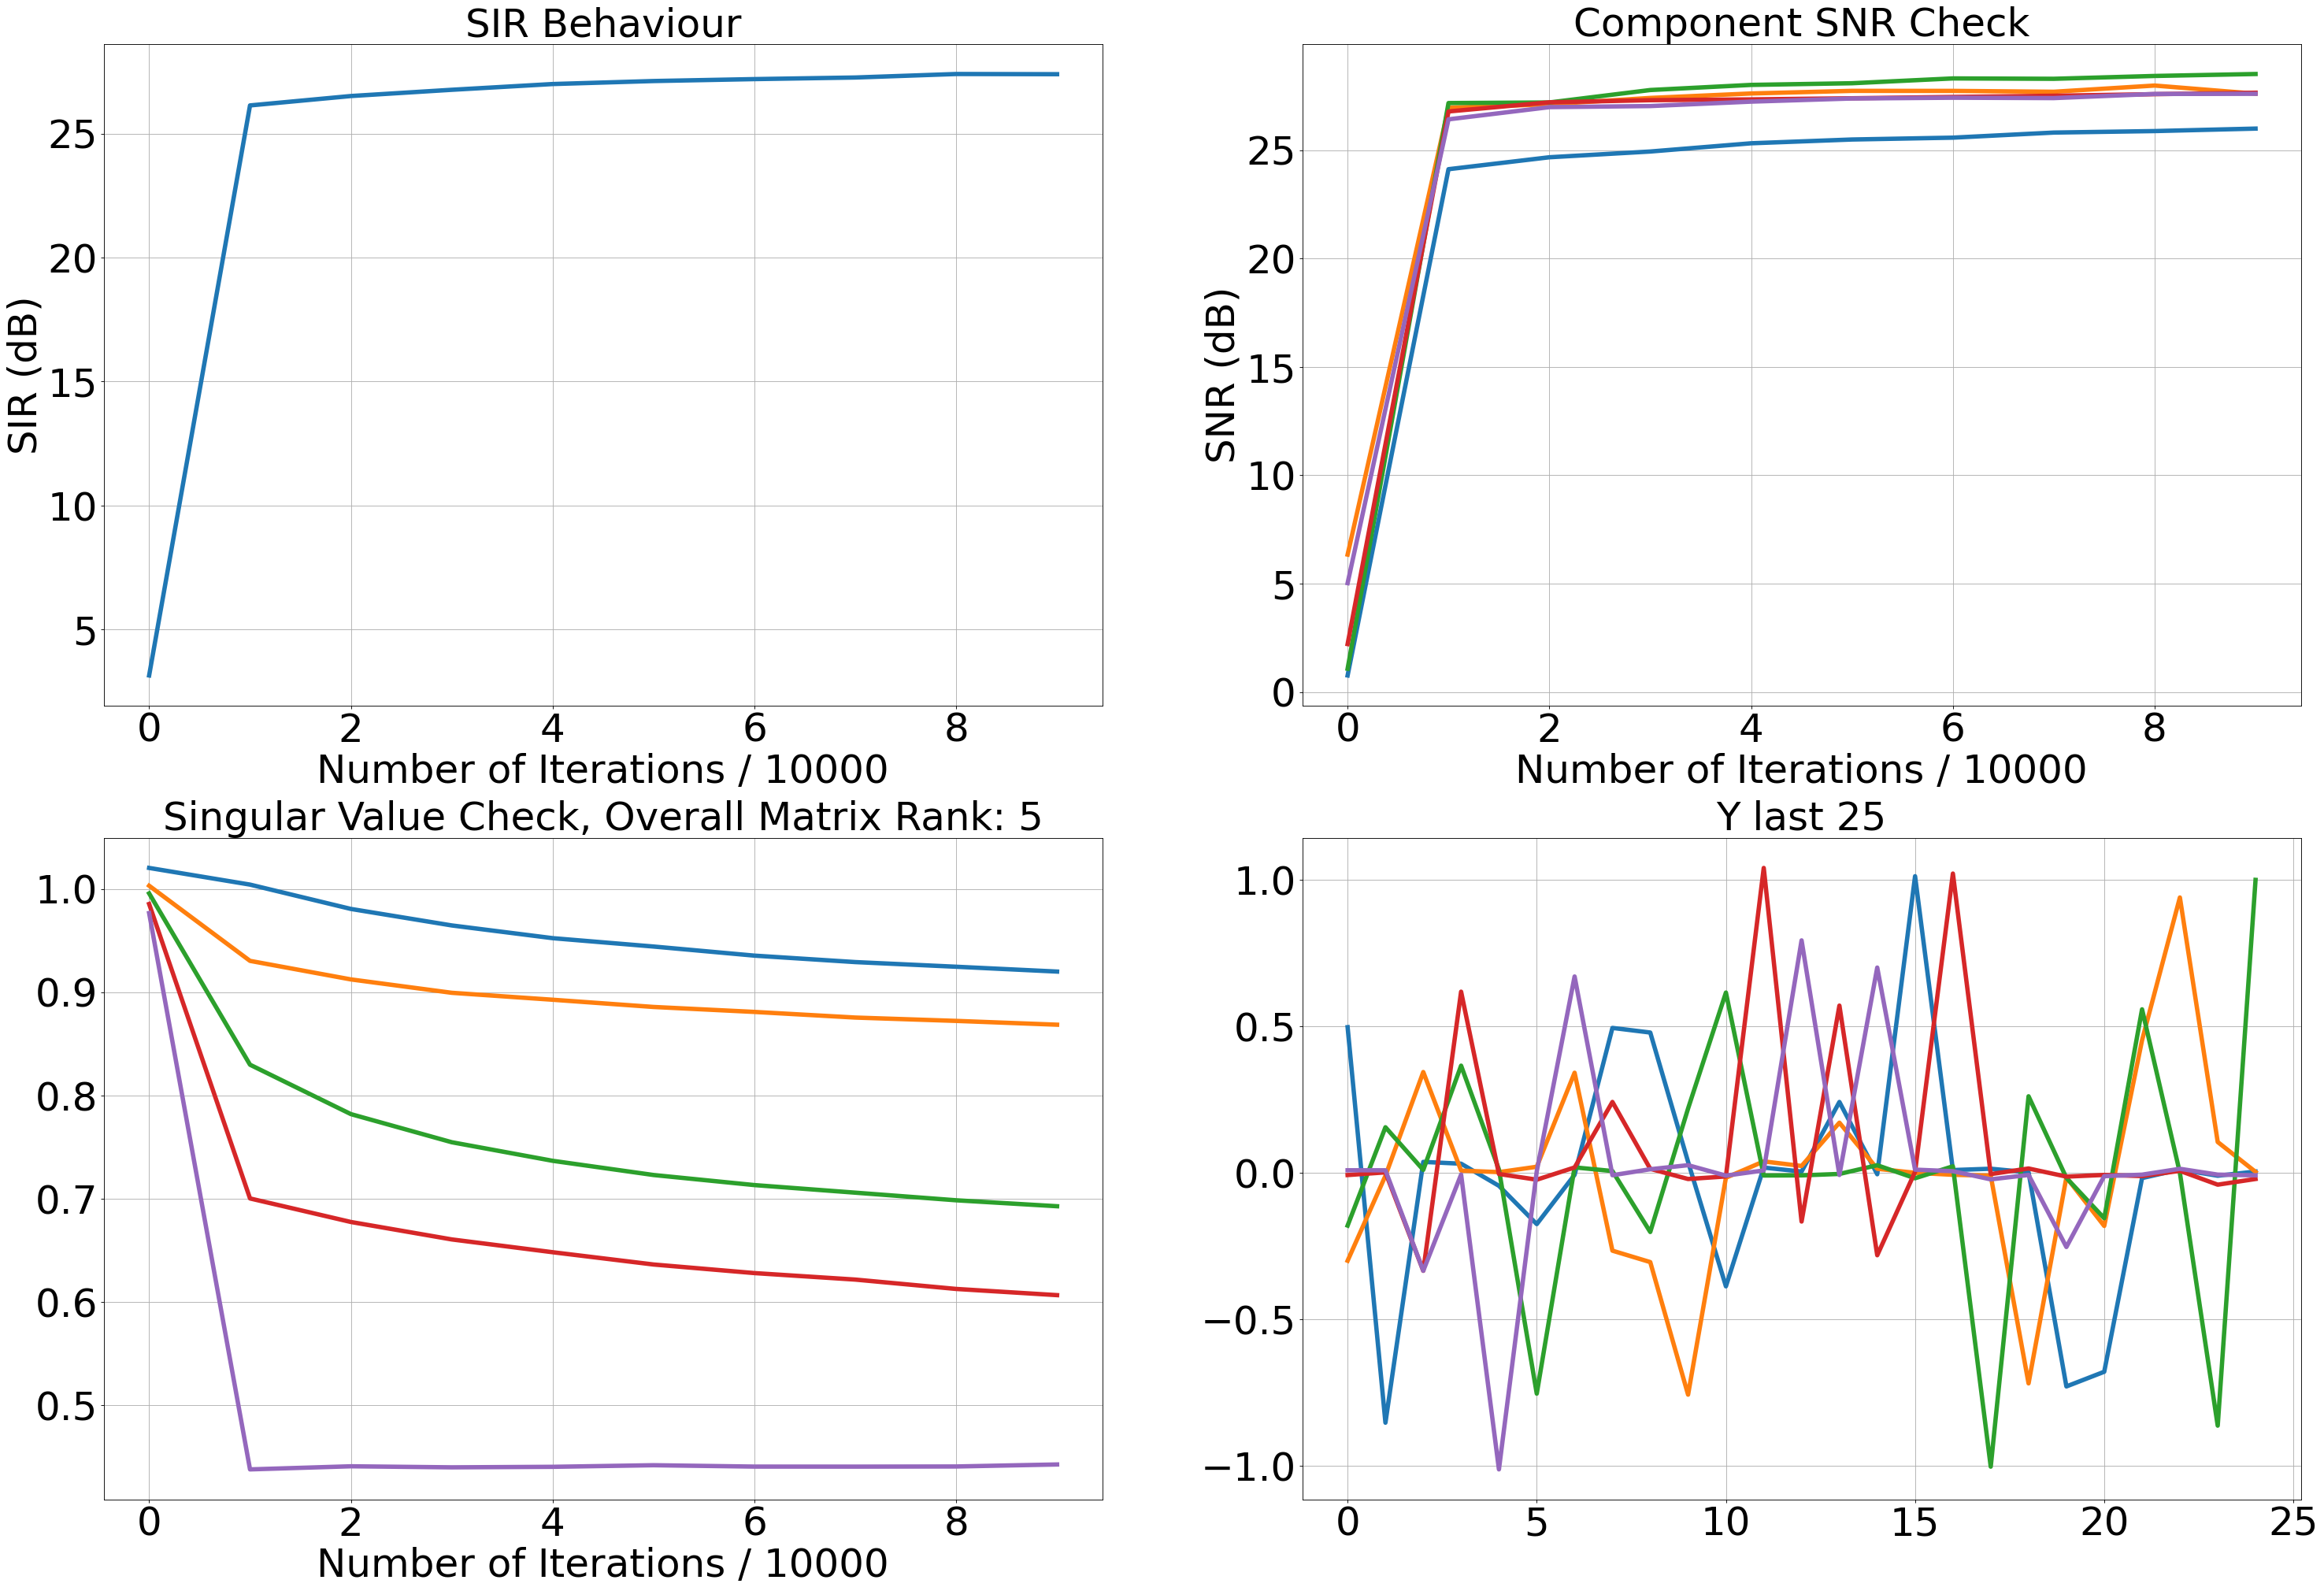

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:57<00:00, 1730.29it/s]


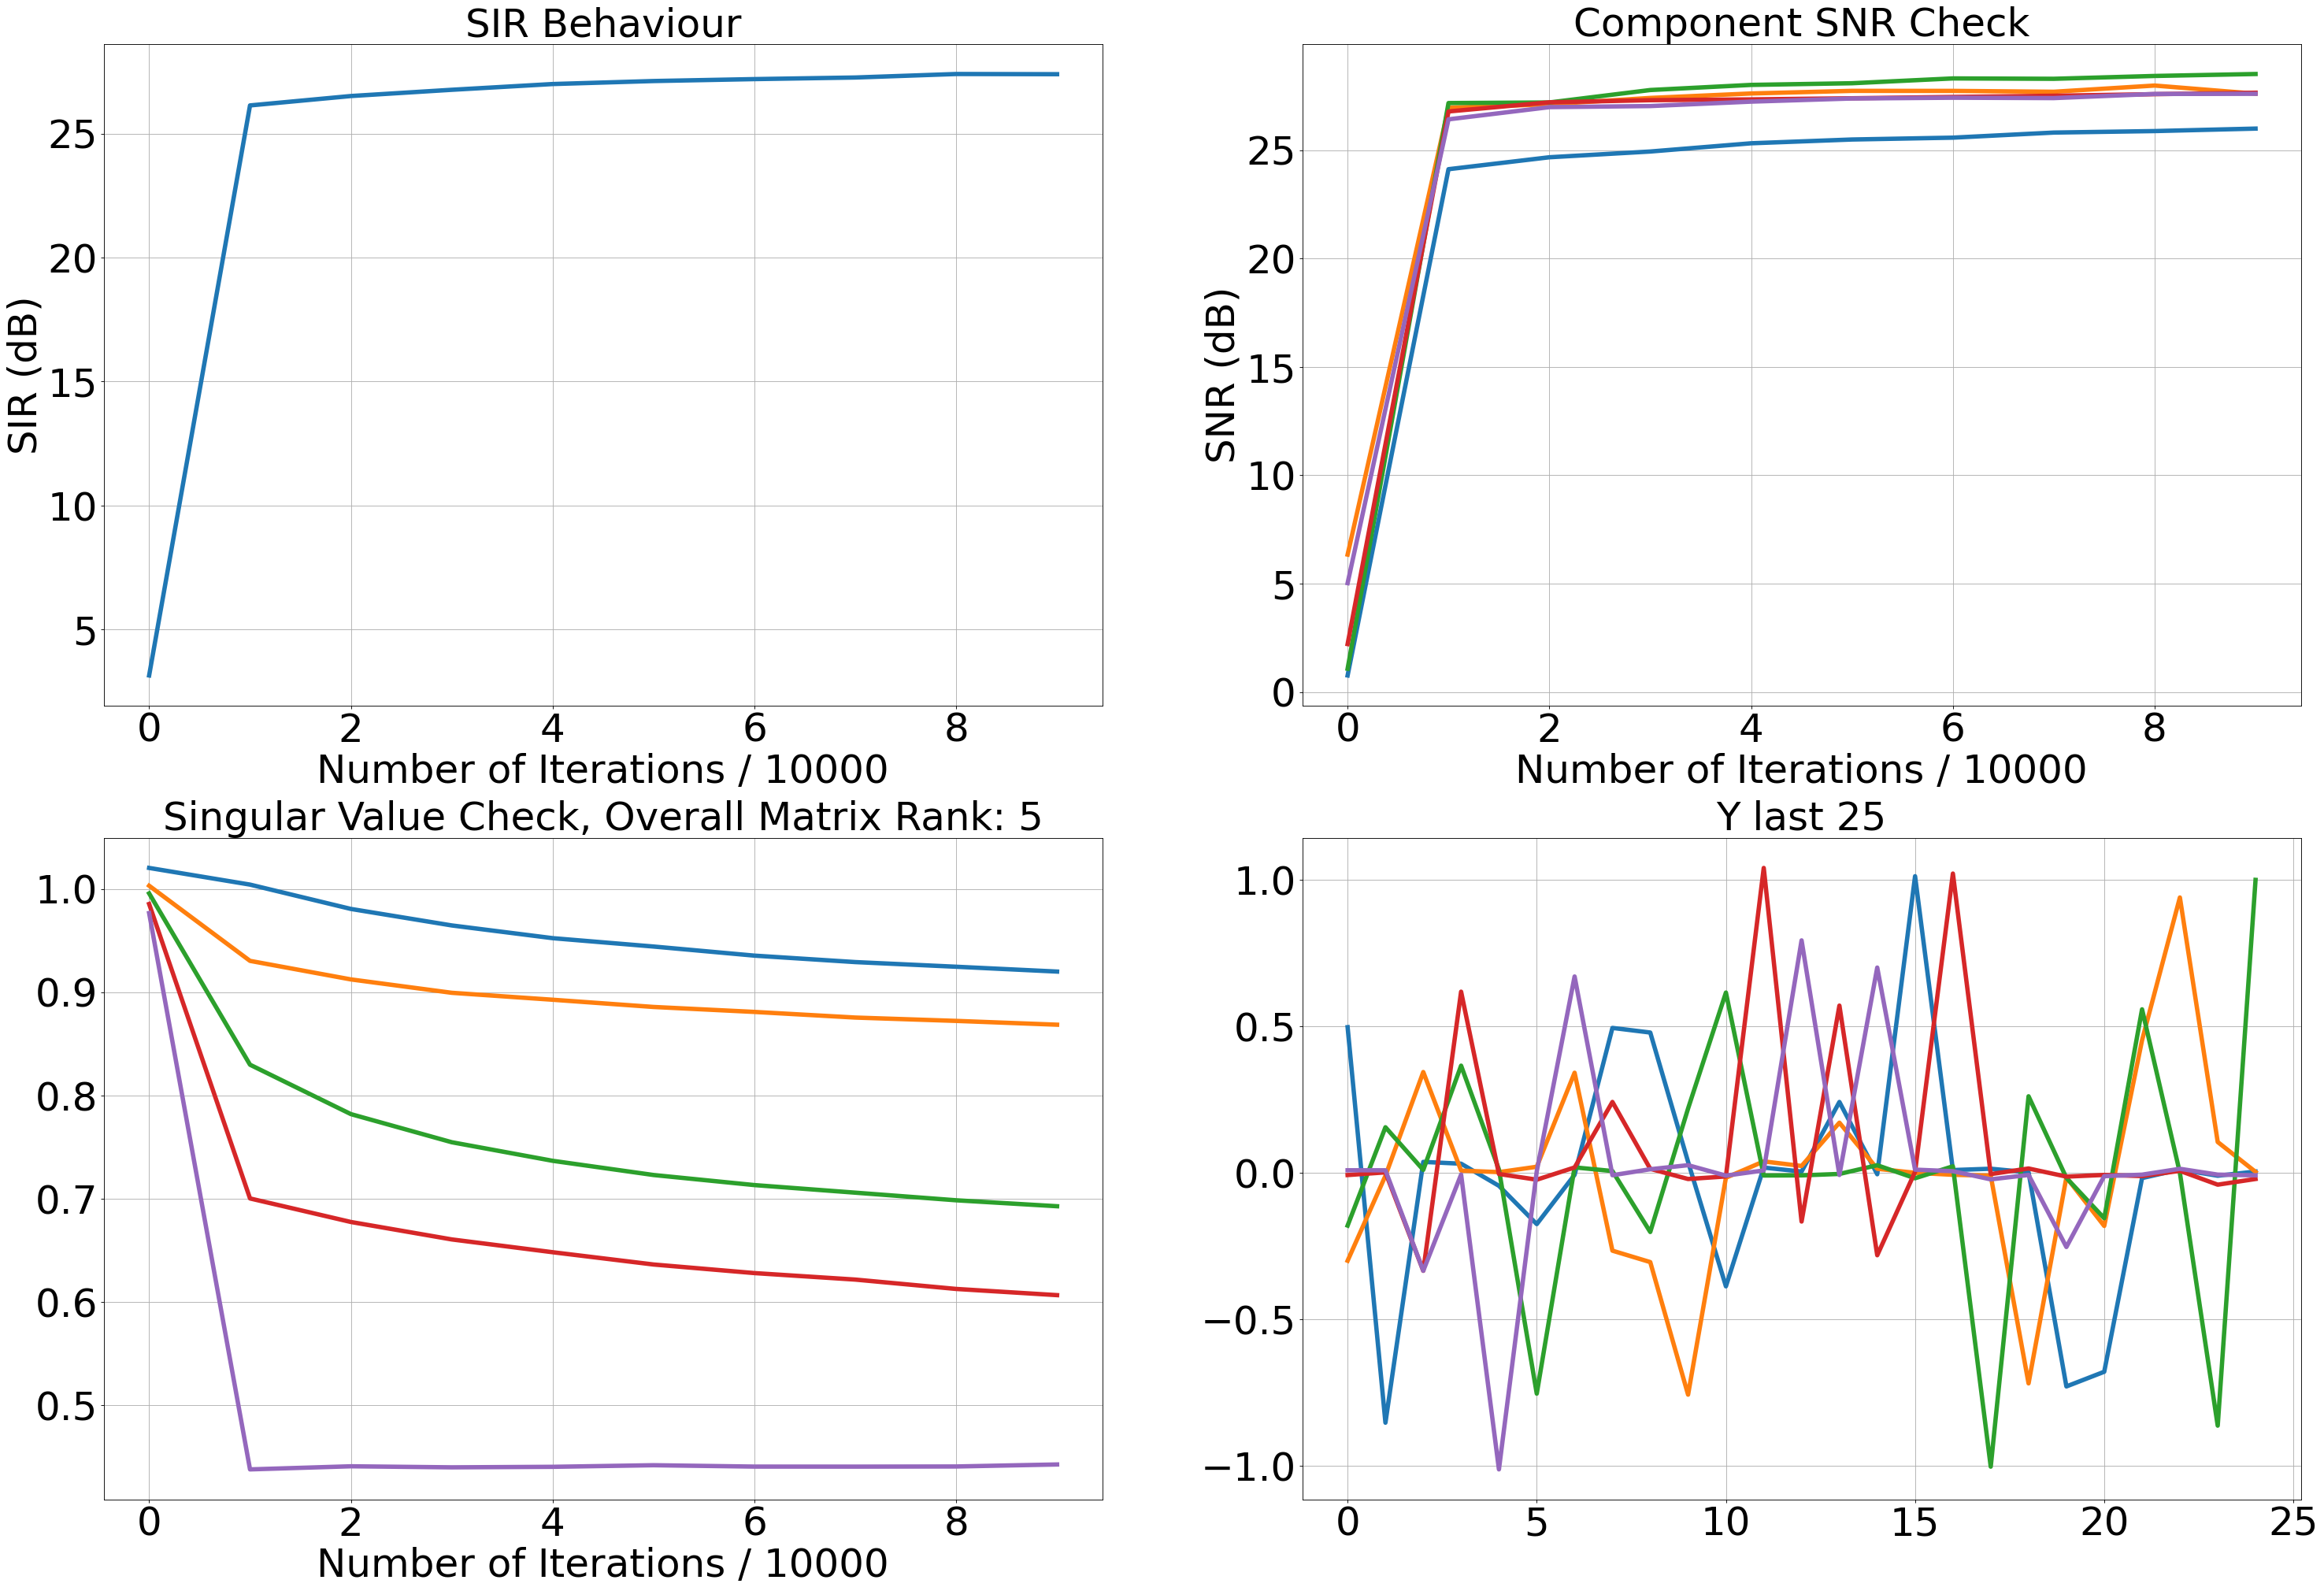

In [3]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "sparse",
                ### Optimization parameters
                "lambda_lateral" : 0.99,
                "gamma_predictive" : 150,
                ### Learning rates 
                "lr_W" : 5 * 1e-2,
                "neural_lr_start" : 0.05,
                "neural_lr_stop" : 1e-4,
                "stlambda_lr" : 0.5,
                "neural_dynamics_iterations" : 100,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_index",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrBSS(**hyperparam_dict)
model.fit(X)

In [4]:
display_matrix(model.C_y)

<IPython.core.display.Math object>

In [5]:
display_matrix(model.mu_y.reshape(1, -1))

<IPython.core.display.Math object>

In [6]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [7]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 27.475129792556707
Component Signal-to-Noise-Ratio (SNR) Values : [26.0572211  28.0700807  28.49836538 27.66534149 27.53706535]



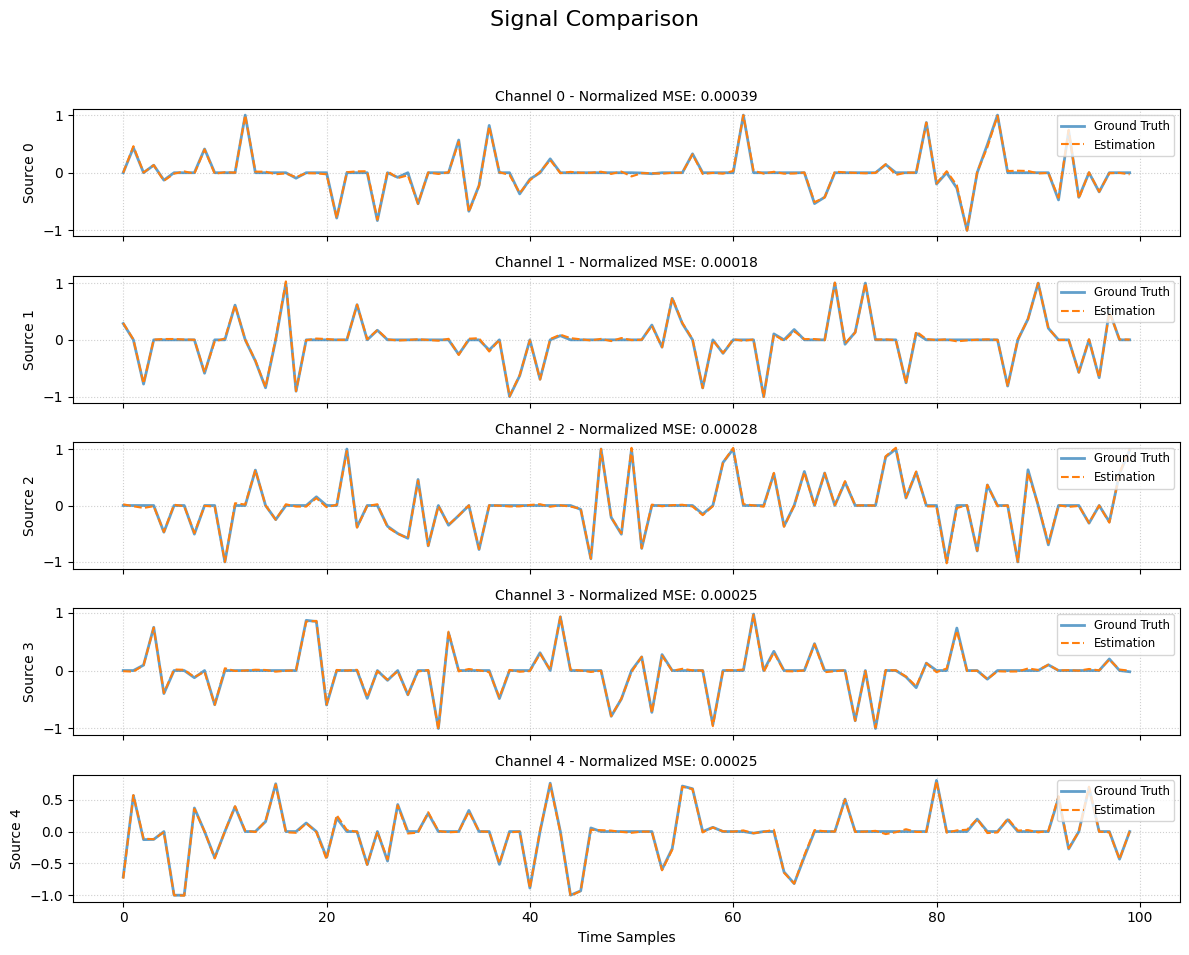

In [8]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])